### In-class exercise:
01. Read CSV file (dataFile.csv)

In [1]:
import pandas as pd

df = pd.read_csv("dataFile.csv", header=None)
print(df.head())

      0      1      2       3      4        5      6      7      8      9   \
0  0.357 -0.309  0.242 -0.2530 -0.282  0.00649 -0.216  0.228  1.700  0.229   
1 -1.050  1.630 -0.155  1.6800  1.670  1.04000 -0.331  0.257  0.367 -0.811   
2 -1.600  0.376 -1.480 -0.0555  0.147 -1.15000 -1.640  0.576  1.350  0.311   
3 -0.950 -1.010  0.646 -0.8660 -0.941 -0.11400  0.594 -0.220  0.646 -1.710   
4 -0.515 -0.393  0.871 -0.1500 -0.266  0.54900  0.402  0.326 -1.560 -0.884   

   ...     41     42     43     44      45      46     47     48     49  50  
0  ... -1.060 -1.090  0.996 -1.190  1.1200  1.1200  0.582  0.299  0.886   0  
1  ...  1.500  0.778  0.783  1.000  0.0949  0.0949 -0.172 -1.600  0.506   1  
2  ...  0.982  0.769  0.602  0.330 -1.6400 -1.6400 -0.588 -1.090  0.029   1  
3  ... -0.382  1.650 -0.403 -1.100  1.1500  1.1500  1.410  1.490 -0.111   0  
4  ...  0.775 -0.848  1.370 -0.785  0.3610  0.3610 -1.700  0.898 -0.512   1  

[5 rows x 51 columns]


02. Review dataset description

In [2]:
print("-------df.info()-------")
print(df.info())
print("-------df.describe()-------")
print(df.describe())
print("-------df.columns.tolist()-------")
print(df.columns.tolist())

-------df.info()-------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       5000 non-null   float64
 1   1       5000 non-null   float64
 2   2       5000 non-null   float64
 3   3       5000 non-null   float64
 4   4       5000 non-null   float64
 5   5       5000 non-null   float64
 6   6       5000 non-null   float64
 7   7       5000 non-null   float64
 8   8       5000 non-null   float64
 9   9       5000 non-null   float64
 10  10      5000 non-null   float64
 11  11      5000 non-null   float64
 12  12      5000 non-null   float64
 13  13      5000 non-null   float64
 14  14      5000 non-null   float64
 15  15      5000 non-null   float64
 16  16      5000 non-null   float64
 17  17      5000 non-null   float64
 18  18      5000 non-null   float64
 19  19      5000 non-null   float64
 20  20      5000 non-null   float64
 21  21      5000 

03. Does it look like for classification or regression? It's classification.

In [3]:
df.columns = [f"feature_{i}" for i in range(50)] + ["target"]

df["target"] = df["target"].astype(int)

print(df["target"].value_counts())
print(df.head())

target
0    2502
1    2498
Name: count, dtype: int64
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0      0.357     -0.309      0.242    -0.2530     -0.282    0.00649   
1     -1.050      1.630     -0.155     1.6800      1.670    1.04000   
2     -1.600      0.376     -1.480    -0.0555      0.147   -1.15000   
3     -0.950     -1.010      0.646    -0.8660     -0.941   -0.11400   
4     -0.515     -0.393      0.871    -0.1500     -0.266    0.54900   

   feature_6  feature_7  feature_8  feature_9  ...  feature_41  feature_42  \
0     -0.216      0.228      1.700      0.229  ...      -1.060      -1.090   
1     -0.331      0.257      0.367     -0.811  ...       1.500       0.778   
2     -1.640      0.576      1.350      0.311  ...       0.982       0.769   
3      0.594     -0.220      0.646     -1.710  ...      -0.382       1.650   
4      0.402      0.326     -1.560     -0.884  ...       0.775      -0.848   

   feature_43  feature_44  feature_45  feature_46  

04. Create visualisations to understand the data

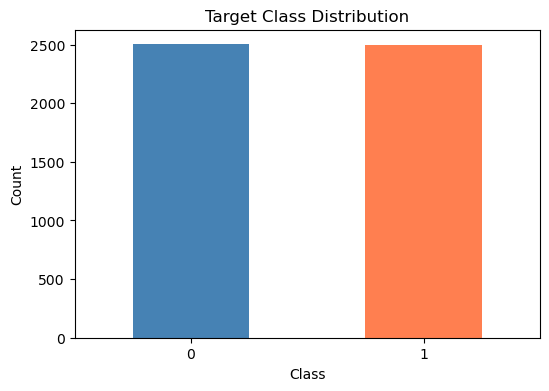

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(6, 4))
df["target"].value_counts().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

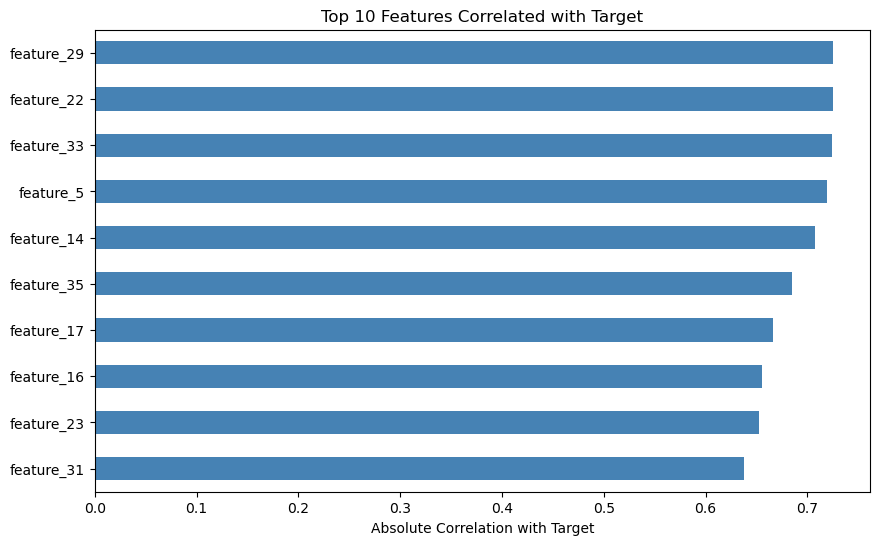

In [7]:
correlations = df.corr()["target"].drop("target").abs().sort_values(ascending=False)
top_features = correlations.head(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh", color="steelblue")
plt.xlabel("Absolute Correlation with Target")
plt.title("Top 10 Features Correlated with Target")
plt.gca().invert_yaxis()
plt.show()

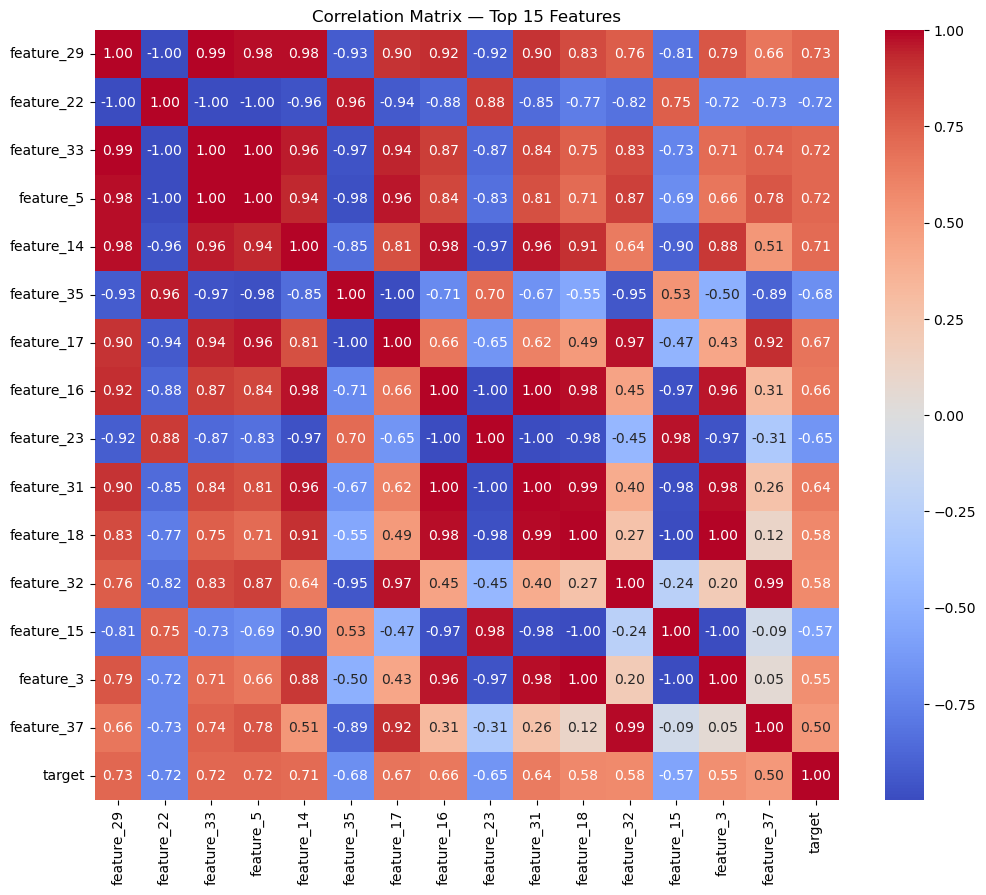

In [9]:
top_15 = correlations.head(15).index.tolist() + ["target"]

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_15].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Top 15 Features")
plt.show()

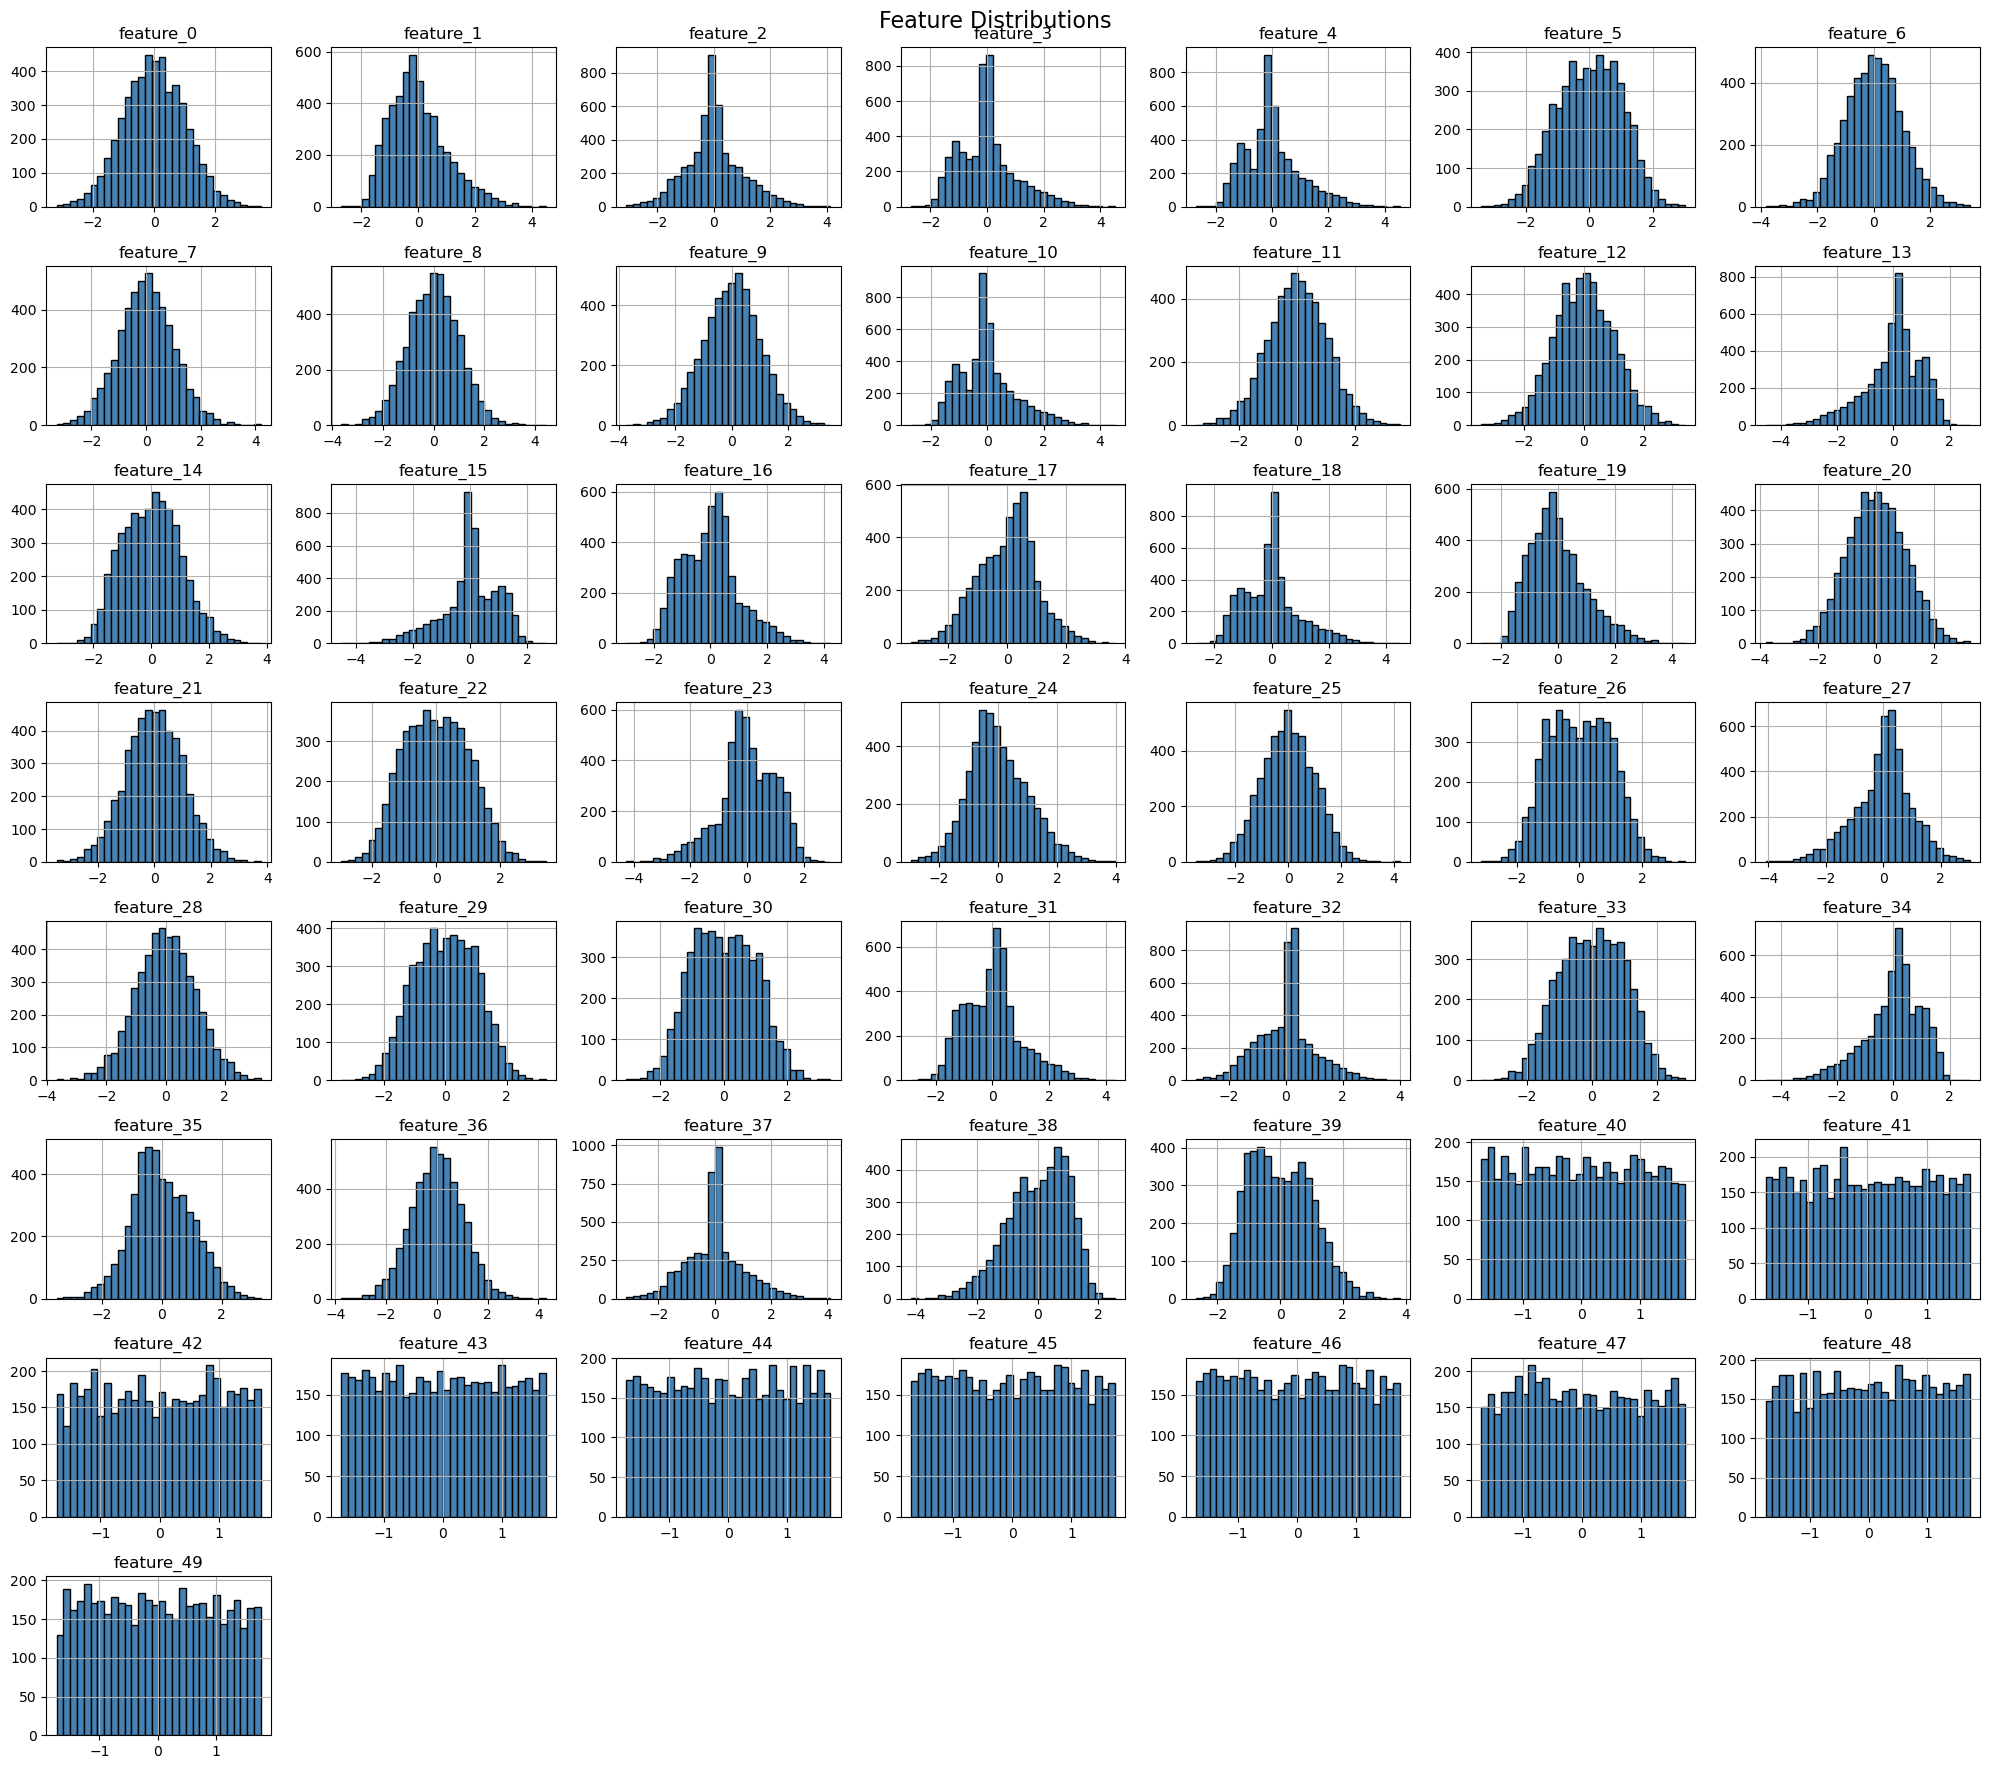

In [10]:
df.drop("target", axis=1).hist(bins=30, figsize=(20, 18), color="steelblue", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

05. Identify outliers using boxplots

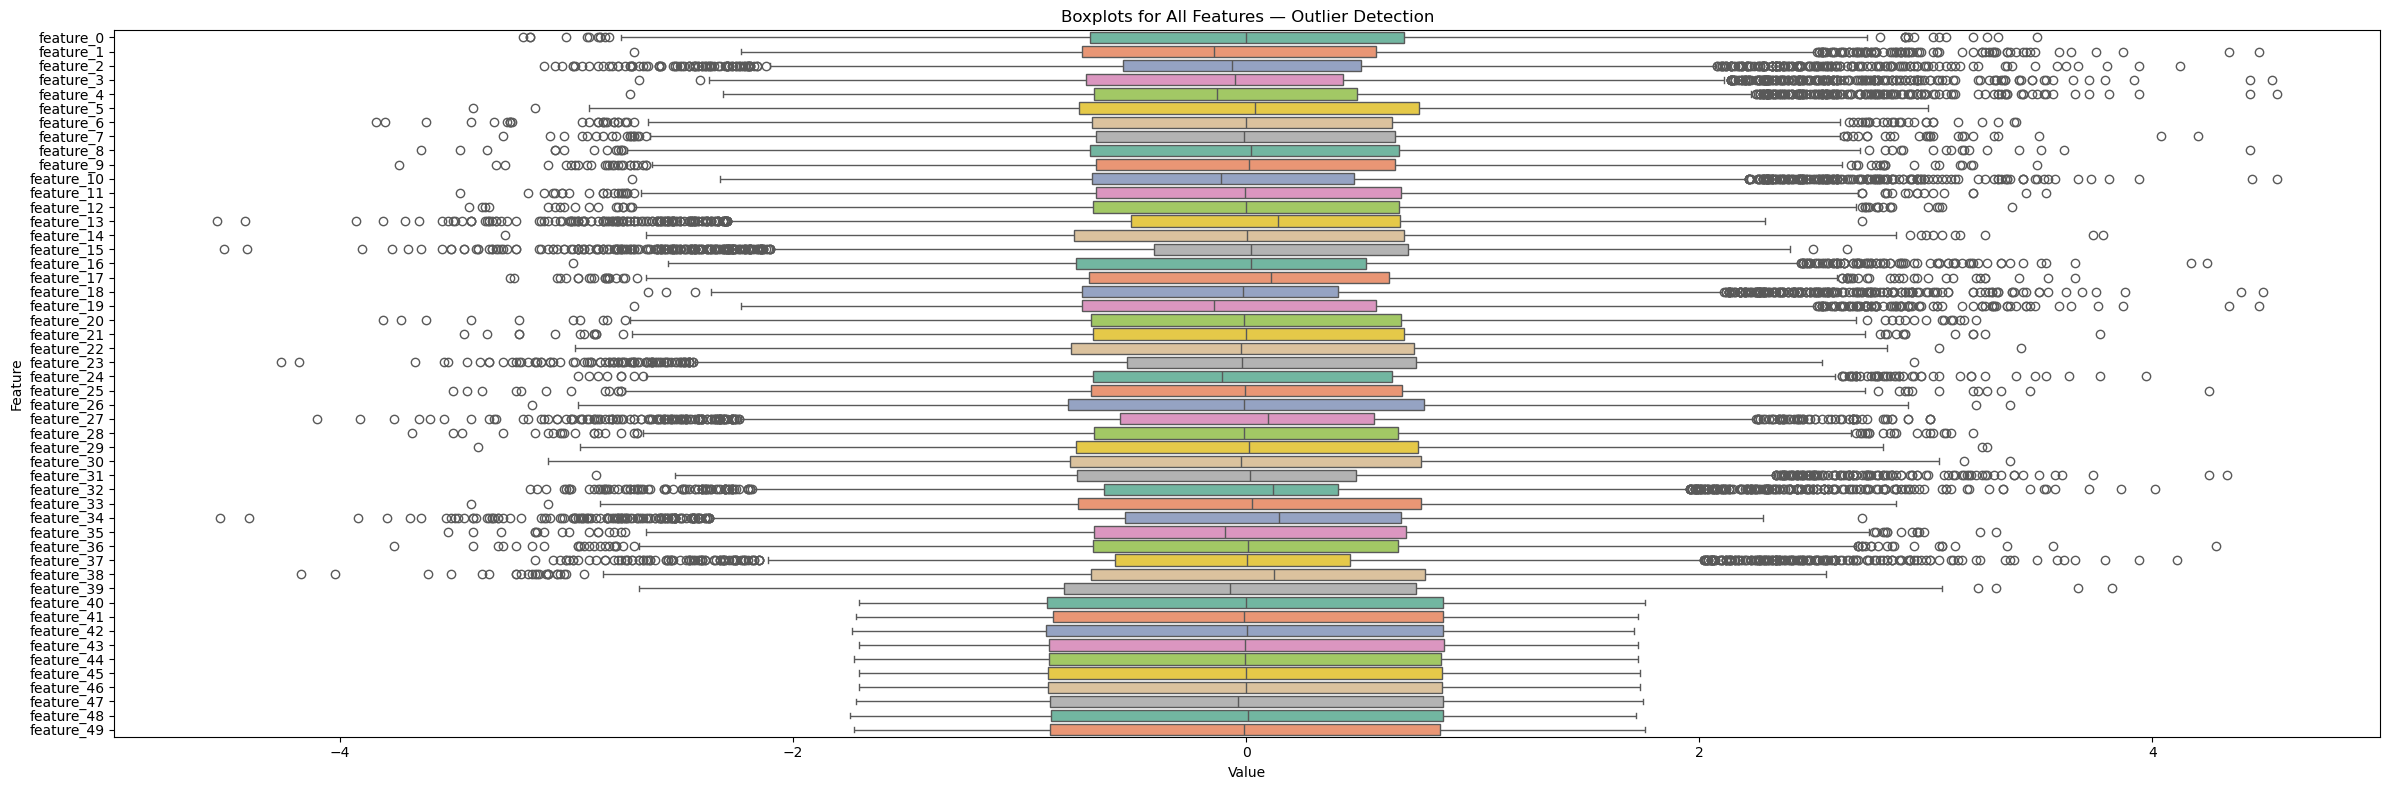

In [11]:
plt.figure(figsize=(24, 8))
sns.boxplot(data=df.drop("target", axis=1), orient="h", palette="Set2")
plt.title("Boxplots for All Features — Outlier Detection")
plt.xlabel("Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

06. Create pipeline with baseline model (Logistic Regression or naive Bayes)

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

Train set: (4000, 50)
Test set:  (1000, 50)


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate
print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
Accuracy: 0.8450

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       482
           1       0.86      0.84      0.85       518

    accuracy                           0.84      1000
   macro avg       0.84      0.85      0.84      1000
weighted avg       0.85      0.84      0.85      1000



In [14]:
from sklearn.naive_bayes import GaussianNB

# Create pipeline
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

# Train
nb_pipeline.fit(X_train, y_train)

# Predict
y_pred_nb = nb_pipeline.predict(X_test)

# Evaluate
print("=" * 50)
print("NAIVE BAYES")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

NAIVE BAYES
Accuracy: 0.8230

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       482
           1       0.84      0.81      0.83       518

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



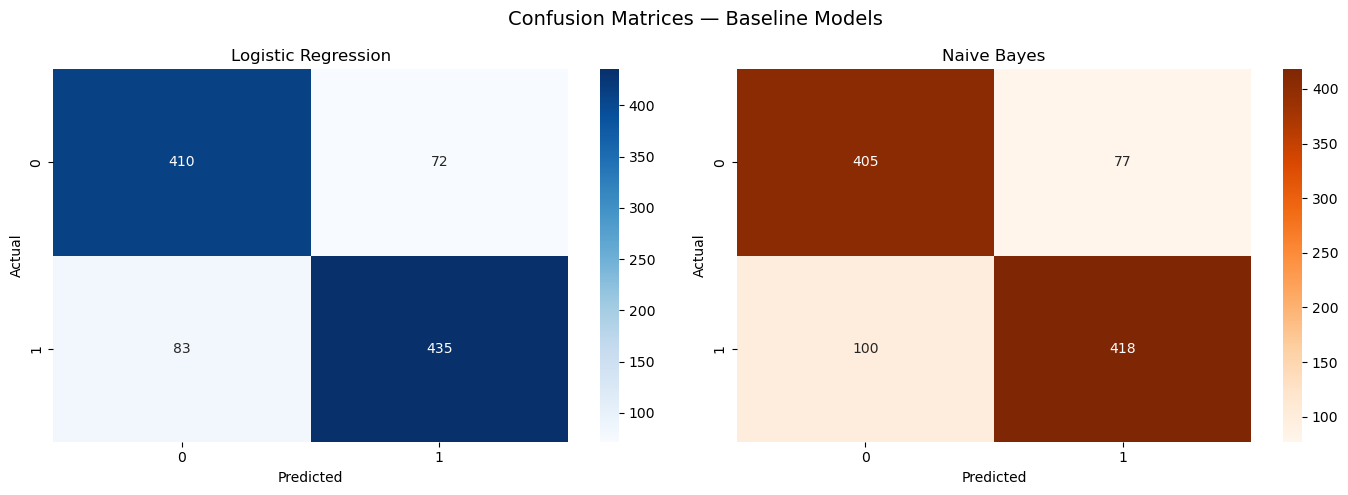

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", 
            cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Naive Bayes
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt="d", 
            cmap="Oranges", ax=axes[1])
axes[1].set_title("Naive Bayes")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Baseline Models", fontsize=14)
plt.tight_layout()
plt.show()

07. Create pipeline with advanced model (Random Forest, Gradient Boosting, ExtraTrees, etc)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy: 0.9300

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       482
           1       0.94      0.93      0.93       518

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=3, 
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

print("=" * 50)
print("GRADIENT BOOSTING")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

GRADIENT BOOSTING
Accuracy: 0.9270

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       482
           1       0.93      0.92      0.93       518

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



In [18]:
from sklearn.ensemble import ExtraTreesClassifier

et_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

et_pipeline.fit(X_train, y_train)
y_pred_et = et_pipeline.predict(X_test)

print("=" * 50)
print("EXTRA TREES")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_et):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_et))

EXTRA TREES
Accuracy: 0.9300

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       482
           1       0.93      0.93      0.93       518

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



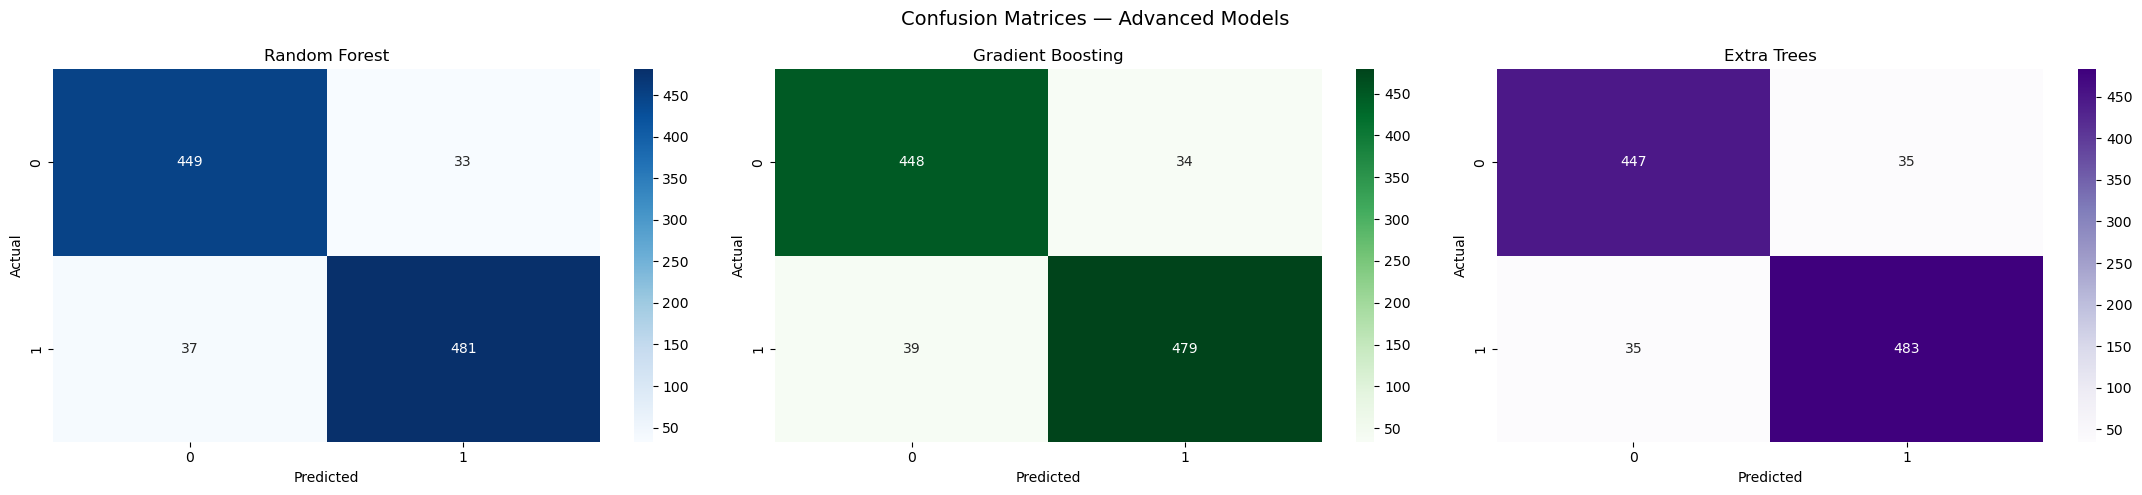

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "Extra Trees": y_pred_et,
}

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
colors = ["Blues", "Greens", "Purples", "Oranges"]

for i, (name, preds) in enumerate(models.items()):
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt="d",
                cmap=colors[i], ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Advanced Models", fontsize=14)
plt.tight_layout()
plt.show()

08. Compare results using cross-validation

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    ExtraTreesClassifier
)
import numpy as np
import pandas as pd

# Define all pipelines
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42))
    ]),
    "Extra Trees": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ])
}

# Run 5-Fold Cross-Validation for each model
results = {}
print("Running Cross-Validation...\n")

for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy", n_jobs=-1)
    results[name] = scores
    print(f"{name:25s} | Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Running Cross-Validation...

Logistic Regression       | Accuracy: 0.8564 ± 0.0055
Naive Bayes               | Accuracy: 0.8430 ± 0.0052
Random Forest             | Accuracy: 0.9348 ± 0.0035
Gradient Boosting         | Accuracy: 0.9278 ± 0.0037
Extra Trees               | Accuracy: 0.9348 ± 0.0063


In [25]:
cv_results = pd.DataFrame({
    "Model": results.keys(),
    "Mean Accuracy": [scores.mean() for scores in results.values()],
    "Std Deviation": [scores.std() for scores in results.values()],
    "Min Accuracy": [scores.min() for scores in results.values()],
    "Max Accuracy": [scores.max() for scores in results.values()]
})

cv_results = cv_results.sort_values("Mean Accuracy", ascending=False)
print("\n" + "=" * 70)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("=" * 70)
print(cv_results.to_string(index=False))


CROSS-VALIDATION RESULTS (5-Fold)
              Model  Mean Accuracy  Std Deviation  Min Accuracy  Max Accuracy
      Random Forest         0.9348       0.003544         0.931         0.940
        Extra Trees         0.9348       0.006337         0.926         0.943
  Gradient Boosting         0.9278       0.003655         0.923         0.932
Logistic Regression         0.8564       0.005463         0.850         0.864
        Naive Bayes         0.8430       0.005177         0.836         0.852


09. Create a pipeline with filter feature selection (SelectKBest)

In [28]:
from sklearn.feature_selection import SelectKBest, f_classif

skb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=10)),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# Train & Evaluate
skb_pipeline.fit(X_train, y_train)
y_pred_skb = skb_pipeline.predict(X_test)

print("=" * 50)
print("SELECTKBEST (k=10) + RANDOM FOREST")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_skb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_skb))

SELECTKBEST (k=10) + RANDOM FOREST
Accuracy: 0.9170

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       482
           1       0.91      0.93      0.92       518

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [29]:
# Get selected feature names
selector = skb_pipeline.named_steps["selector"]
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print("=" * 50)
print(f"SELECTED FEATURES ({len(selected_features)} out of {X.shape[1]})")
print("=" * 50)
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

SELECTED FEATURES (10 out of 50)
  1. feature_5
  2. feature_14
  3. feature_16
  4. feature_17
  5. feature_22
  6. feature_23
  7. feature_29
  8. feature_31
  9. feature_33
  10. feature_35


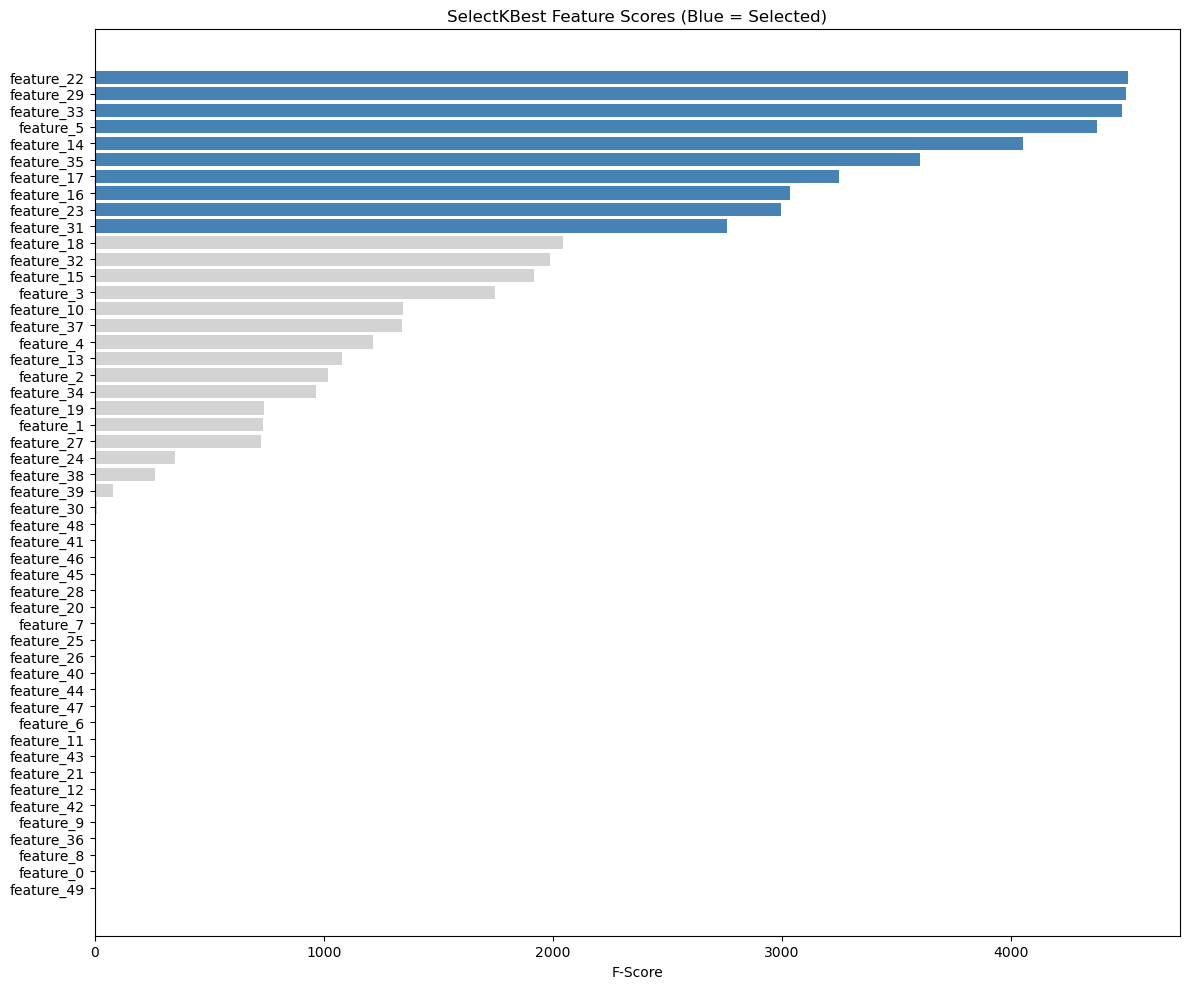

In [30]:
# Get scores for all features
scores = selector.scores_
score_df = pd.DataFrame({
    "Feature": X.columns,
    "Score": scores,
    "Selected": selected_mask
}).sort_values("Score", ascending=False)

# Plot
plt.figure(figsize=(12, 10))
colors = ["steelblue" if s else "lightgray" for s in score_df["Selected"]]
plt.barh(score_df["Feature"], score_df["Score"], color=colors)
plt.xlabel("F-Score")
plt.title("SelectKBest Feature Scores (Blue = Selected)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
k_range = range(1, X.shape[1] + 1)  # 1 to 50
k_scores = []

print("Testing different K values...\n")

for k in k_range:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=k)),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ])
    
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy", n_jobs=-1)
    k_scores.append(scores.mean())

# Find best K
best_k = k_range[np.argmax(k_scores)]
best_score = max(k_scores)

print(f"Best K: {best_k} features")
print(f"Best Accuracy: {best_score:.4f}")

Testing different K values...

Best K: 50 features
Best Accuracy: 0.9348


10. Visualise the top features using permutation importance

In [33]:
from sklearn.inspection import permutation_importance

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)

# Compute Permutation Importance on TEST set
perm_importance = permutation_importance(
    pipeline, 
    X_test, 
    y_test, 
    n_repeats=10,       # Shuffle each feature 10 times
    random_state=42, 
    n_jobs=-1,
    scoring="accuracy"
)

print("Permutation Importance computed!")

Permutation Importance computed!


In [34]:
# Organize results
perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
}).sort_values("Importance Mean", ascending=False)

print("=" * 55)
print("TOP 15 FEATURES (Permutation Importance)")
print("=" * 55)
print(perm_df.head(15).to_string(index=False))

TOP 15 FEATURES (Permutation Importance)
   Feature  Importance Mean  Importance Std
feature_32           0.0079        0.002914
feature_19           0.0010        0.001342
feature_48          -0.0003        0.000458
feature_23          -0.0006        0.001356
feature_18          -0.0006        0.001114
feature_46          -0.0007        0.000640
feature_11          -0.0007        0.000458
 feature_3          -0.0007        0.000781
 feature_7          -0.0009        0.001300
feature_10          -0.0010        0.001095
feature_35          -0.0010        0.001549
feature_28          -0.0010        0.000894
feature_45          -0.0010        0.000894
feature_40          -0.0010        0.000894
 feature_8          -0.0013        0.001100


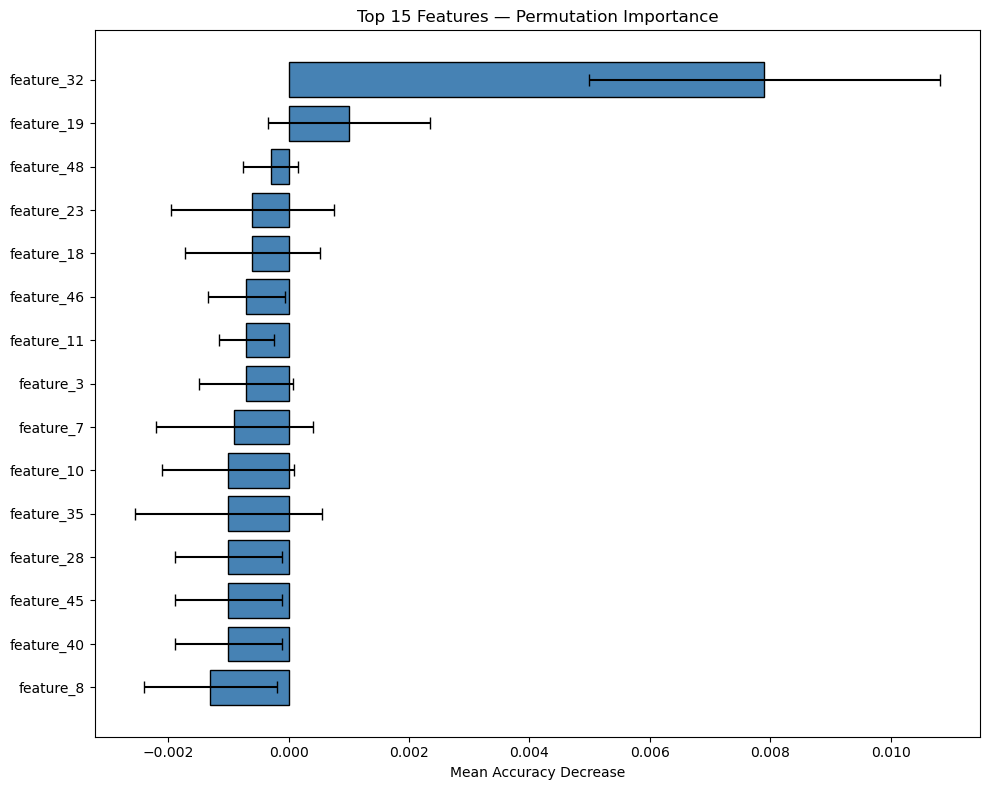

In [35]:
top_15 = perm_df.head(15)

plt.figure(figsize=(10, 8))
plt.barh(
    top_15["Feature"][::-1],
    top_15["Importance Mean"][::-1],
    xerr=top_15["Importance Std"][::-1],
    color="steelblue",
    edgecolor="black",
    capsize=4
)
plt.xlabel("Mean Accuracy Decrease")
plt.title("Top 15 Features — Permutation Importance")
plt.tight_layout()
plt.show()

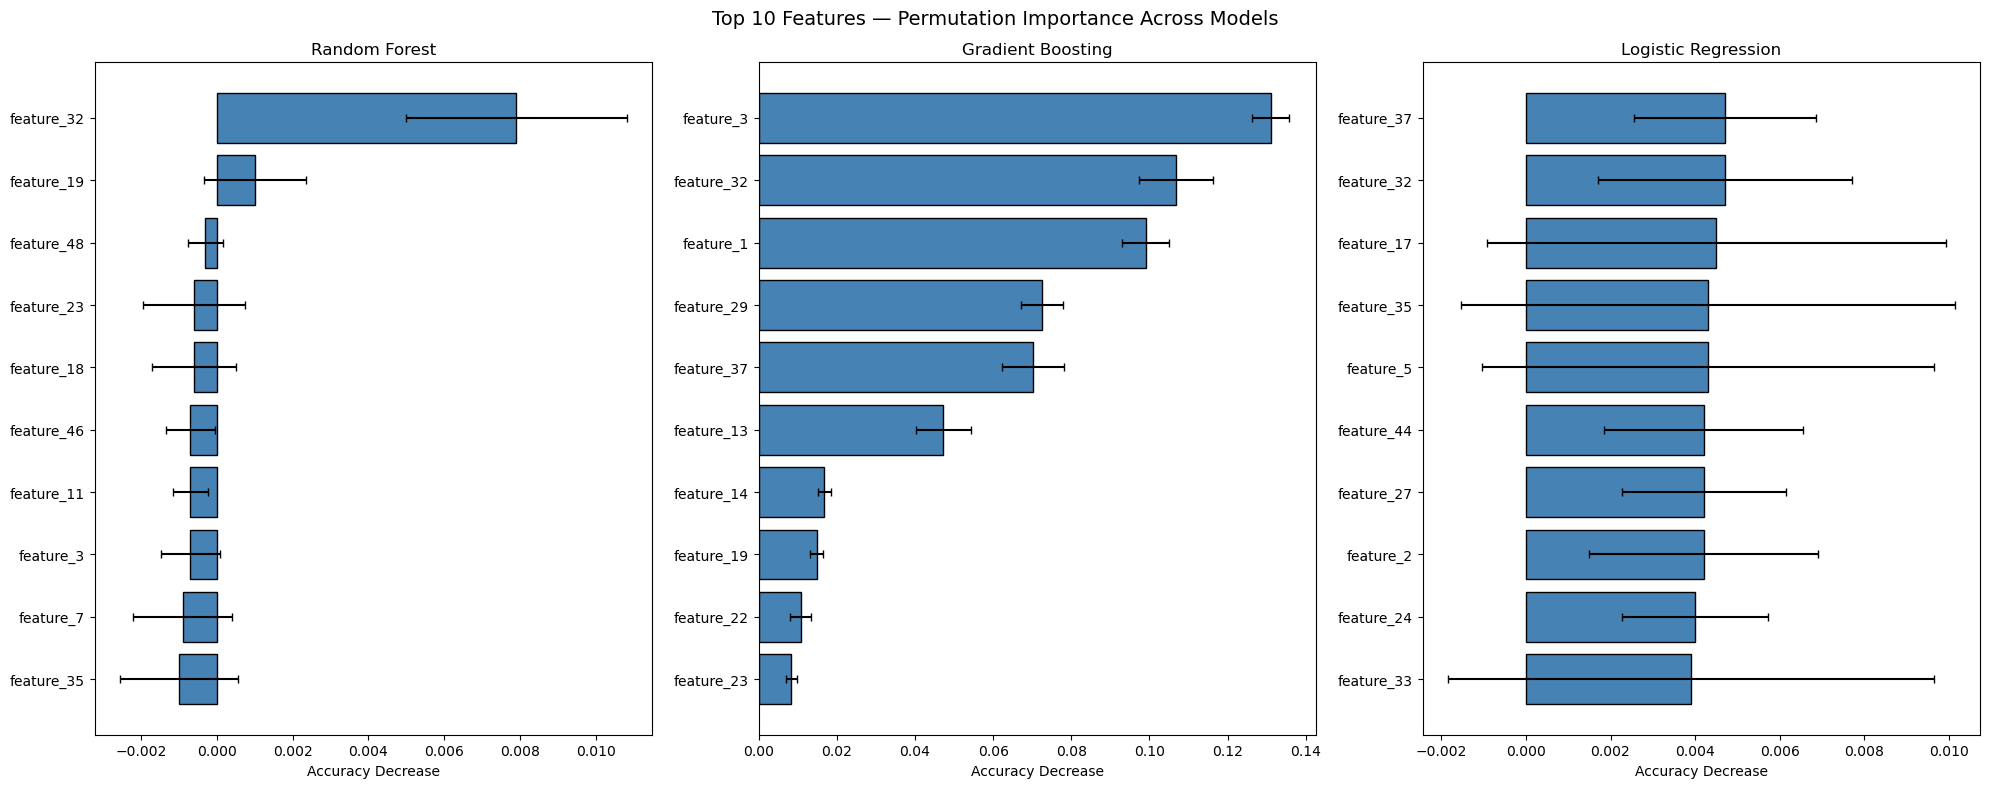

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(n_estimators=200, random_state=42))
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42, max_iter=1000))
    ])
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, (name, pipe) in enumerate(models.items()):
    pipe.fit(X_train, y_train)
    
    perm = permutation_importance(
        pipe, X_test, y_test, 
        n_repeats=10, random_state=42, n_jobs=-1
    )
    
    top_idx = np.argsort(perm.importances_mean)[-10:]
    
    axes[i].barh(
        X.columns[top_idx],
        perm.importances_mean[top_idx],
        xerr=perm.importances_std[top_idx],
        color="steelblue",
        edgecolor="black",
        capsize=3
    )
    axes[i].set_title(name)
    axes[i].set_xlabel("Accuracy Decrease")

plt.suptitle("Top 10 Features — Permutation Importance Across Models", fontsize=14)
plt.tight_layout()
plt.show()